In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from requests import head

# RUL = Entire life of the engine (The last cycle) - Current cycle


INDEX_COLS = ["unit", "cycle"]
SETTING_COLS = ["op_setting1","op_setting2","op_setting3"]
SENSOR_COLS = [f"sensor_{i}" for i in range(1,22)] # 6th -26th columns (n=21)
ALL_COLS = INDEX_COLS + SETTING_COLS + SENSOR_COLS

SENSOR_NAMES = {
    "sensor_1": "T2 (Fan inlet temp, R)",
    "sensor_2": "T24 (LPC outlet temp, R)",
    "sensor_3": "T30 (HPC outlet temp, R)",
    "sensor_4": "T50 (LPT outlet temp, R)",
    "sensor_5": "P2 (Fan inlet pressure, psia)",
    "sensor_6": "P15 (Bypass-duct pressure, psia)",
    "sensor_7": "P30 (HPC outlet pressure, psia)",
    "sensor_8": "Nf (Physical fan speed, rpm)",
    "sensor_9": "Nc (Physical core speed, rpm)",
    "sensor_10": "epr (Engine pressure ratio)",
    "sensor_11": "Ps30 (HPC outlet static pressure, psia)",
    "sensor_12": "phi (Fuel flow / Ps30, pps/psi)",
    "sensor_13": "NRf (Corrected fan speed, rpm)",
    "sensor_14": "NRc (Corrected core speed, rpm)",
    "sensor_15": "BPR (Bypass ratio)",
    "sensor_16": "farB (Burner fuel-air ratio)",
    "sensor_17": "htBleed (Bleed enthalpy)",
    "sensor_18": "Nf_dmd (Demanded fan speed, rpm)",
    "sensor_19": "PCNfR_dmd (Demanded corrected fan speed, rpm)",
    "sensor_20": "W31 (HPT coolant bleed, lbm/s)",
    "sensor_21": "W32 (LPT coolant bleed, lbm/s)",
}

def load_data(filepath : str) -> pd.DataFrame:
    df = pd.read_csv(filepath, sep=r"\s+", header=None) # header not exists, no comma, (s+) all lengths of spaces would be separated since - sign in the dataset
    df = df.iloc[:, :len(ALL_COLS)]
    df.columns = ALL_COLS
    return df

df = load_data("../data/test_FD001.txt")
df.info()
df.shape
df.describe()
df["unit"].nunique()
df.groupby("unit")["cycle"].max().describe()


<class 'pandas.DataFrame'>
RangeIndex: 13096 entries, 0 to 13095
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit         13096 non-null  int64  
 1   cycle        13096 non-null  int64  
 2   op_setting1  13096 non-null  float64
 3   op_setting2  13096 non-null  float64
 4   op_setting3  13096 non-null  float64
 5   sensor_1     13096 non-null  float64
 6   sensor_2     13096 non-null  float64
 7   sensor_3     13096 non-null  float64
 8   sensor_4     13096 non-null  float64
 9   sensor_5     13096 non-null  float64
 10  sensor_6     13096 non-null  float64
 11  sensor_7     13096 non-null  float64
 12  sensor_8     13096 non-null  float64
 13  sensor_9     13096 non-null  float64
 14  sensor_10    13096 non-null  float64
 15  sensor_11    13096 non-null  float64
 16  sensor_12    13096 non-null  float64
 17  sensor_13    13096 non-null  float64
 18  sensor_14    13096 non-null  float64
 19  sensor_15    13

count    100.000000
mean     130.960000
std       53.593479
min       31.000000
25%       88.750000
50%      133.500000
75%      164.250000
max      303.000000
Name: cycle, dtype: float64

unit
1       31
2       49
3      126
4      106
5       98
      ... 
96      97
97     134
98     121
99      97
100    198
Name: cycle, Length: 100, dtype: int64


Text(0.5, 1.0, 'Distribution of Lifetimes of Engines')

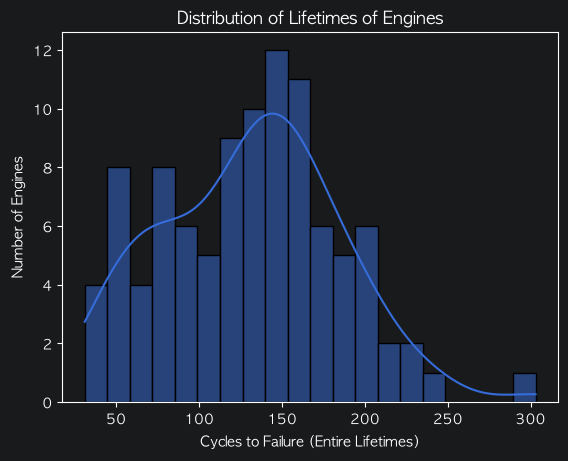

In [23]:
import matplotlib.pyplot as plt

# 맥(Mac)용 기본 한글 폰트(애플고딕) 설정
plt.rc('font', family='AppleGothic')
# 그래프에서 마이너스(-) 기호가 깨지는 문제 해결
plt.rcParams['axes.unicode_minus'] = False

def get_unit_lifetimes(df: pd.DataFrame) -> pd.Series:
    #각 unit의 최대 cycle = 그 엔진의 전체 수명(고장 시점)
    return df.groupby("unit")["cycle"].max()

print(get_unit_lifetimes(df))

lifetimes = get_unit_lifetimes(df)

sns.histplot(lifetimes, bins=20,kde=True)
plt.xlabel("Cycles to Failure (Entire Lifetimes)")
plt.ylabel("Number of Engines")
plt.title("Distribution of Lifetimes of Engines")
